In [37]:
import os
from glob import glob
import time

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
from tqdm.auto import tqdm
from matplotlib.ticker import FuncFormatter

from PIL import Image

from scipy.signal import find_peaks

In [2]:
data_path = "../../../Downloads/archive"

In [3]:
data_stats_files = glob(os.path.join(data_path, 'aggregate/*.csv'))
data_deaths_files = glob(os.path.join(data_path, 'deaths/*.csv'))

for file in data_stats_files + data_deaths_files:
    print(os.path.basename(file))

erangel_img = mpimg.imread(os.path.join(data_path, 'erangel.jpg'))
# erangel_img_pil = Image.fromarray((erangel_img * 255).astype(np.uint8))  # Convert to uint8 and to a PIL Image
# erangel_img_resized = erangel_img_pil.resize((1024, 1024))  # Resize to 1024x1024
# erangel_img = np.array(erangel_img_resized)

erangel_img_pil = Image.open(os.path.join(data_path, 'erangel.jpg'))
erangel_img_resized = erangel_img_pil.resize((256, 256))  # Resize to 1024x1024
erangel_img = np.array(erangel_img_resized)

agg_match_stats_0.csv
agg_match_stats_1.csv
agg_match_stats_2.csv
agg_match_stats_3.csv
agg_match_stats_4.csv
kill_match_stats_final_0.csv
kill_match_stats_final_1.csv
kill_match_stats_final_2.csv
kill_match_stats_final_3.csv
kill_match_stats_final_4.csv


In [4]:
start_time = time.perf_counter()

df = pd.read_csv(data_stats_files[0])

end_time = time.perf_counter()
print(f"Time taken to read the agg_match_stats file: {end_time - start_time:.6f} seconds")

Time taken to read the agg_match_stats file: 26.151416 seconds


In [5]:
start_time = time.perf_counter()

death_df = pd.read_csv(data_deaths_files[0])

end_time = time.perf_counter()
print(f"Time taken to read the kill_match_stats file: {end_time - start_time:.6f} seconds")

Time taken to read the kill_match_stats file: 23.419718 seconds


In [6]:
print(df.head(5))
print(f"Number of rows and columns: {df.shape}")
df = df.dropna()
print(f"Number of rows and columns after dropna: {df.shape}")

                       date  game_size  \
0  2017-11-26T20:59:40+0000         37   
1  2017-11-26T20:59:40+0000         37   
2  2017-11-26T20:59:40+0000         37   
3  2017-11-26T20:59:40+0000         37   
4  2017-11-26T20:59:40+0000         37   

                                            match_id match_mode  party_size  \
0  2U4GBNA0YmnNZYkzjkfgN4ev-hXSrak_BSey_YEG6kIuDG...        tpp           2   
1  2U4GBNA0YmnNZYkzjkfgN4ev-hXSrak_BSey_YEG6kIuDG...        tpp           2   
2  2U4GBNA0YmnNZYkzjkfgN4ev-hXSrak_BSey_YEG6kIuDG...        tpp           2   
3  2U4GBNA0YmnNZYkzjkfgN4ev-hXSrak_BSey_YEG6kIuDG...        tpp           2   
4  2U4GBNA0YmnNZYkzjkfgN4ev-hXSrak_BSey_YEG6kIuDG...        tpp           2   

   player_assists  player_dbno  player_dist_ride  player_dist_walk  \
0               0            1        2870.72400       1784.847780   
1               0            1        2938.40723       1756.079710   
2               0            0           0.00000        224.15

In [7]:
print(death_df.head(5))
print(f"Number of rows and columns: {death_df.shape}")
death_df = death_df.dropna()
print(f"Number of rows and columns after dropna {death_df.shape}")

      killed_by       killer_name  killer_placement  killer_position_x  \
0       Grenade   KrazyPortuguese               5.0          657725.10   
1        SCAR-L  nide2Bxiaojiejie              31.0           93091.37   
2          S686          Ascholes              43.0          366921.40   
3  Down and Out        Weirdo7777               9.0          472014.20   
4          M416         Solayuki1               9.0          473357.80   

   killer_position_y      map  \
0           146275.2  MIRAMAR   
1           722236.4  MIRAMAR   
2           421623.9  MIRAMAR   
3           313274.8  MIRAMAR   
4           318340.5  MIRAMAR   

                                            match_id  time      victim_name  \
0  2U4GBNA0YmnLSqvEycnTjo-KT000vfUnhSA2vfVhVPe1QB...   823  KrazyPortuguese   
1  2U4GBNA0YmnLSqvEycnTjo-KT000vfUnhSA2vfVhVPe1QB...   194      X3evolution   
2  2U4GBNA0YmnLSqvEycnTjo-KT000vfUnhSA2vfVhVPe1QB...   103          CtrlZee   
3  2U4GBNA0YmnLSqvEycnTjo-KT000vfUnhSA2v

In [8]:
maps = death_df['map'].unique()
print(f"Unique map values: {maps}")

Unique map values: ['MIRAMAR' 'ERANGEL']


In [9]:
erangel_death_df = death_df[death_df['map'] == 'ERANGEL']

In [10]:
max_time = erangel_death_df['time'].max()
min_time = erangel_death_df['time'].min()

print(f"Maximum time: {max_time}")
print(f"Minimum time: {min_time}")

Maximum time: 2374
Minimum time: 28


In [11]:
unique_match_ids = df['match_id'].unique()
print(f"Number of unique match_id values: {len(unique_match_ids)}")

death_unique_match_ids = erangel_death_df['match_id'].unique()
print(f"Number of ERANGEL unique match_id values: {len(death_unique_match_ids)}")

valid_match_ids = np.intersect1d(unique_match_ids, death_unique_match_ids)
print(f"Valid match_ids: {len(valid_match_ids)}")

Number of unique match_id values: 149994
Number of ERANGEL unique match_id values: 118838
Valid match_ids: 118835


0 2U4GBNA0Ymk--3atnvB2Cy2-kmfWLqeLwaiFMfmzWQFhCkWmYZiq4XKDsLngboSq
Number of rows for match_id 2U4GBNA0Ymk--3atnvB2Cy2-kmfWLqeLwaiFMfmzWQFhCkWmYZiq4XKDsLngboSq: 81


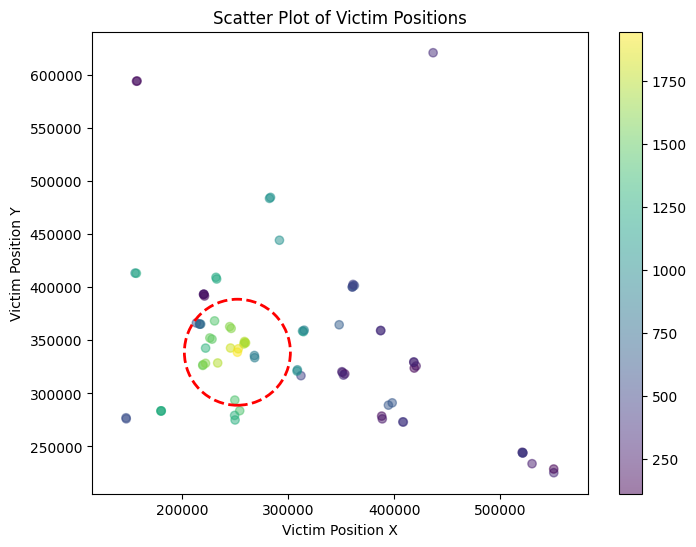


1 2U4GBNA0Ymk--3eiHoaWZvPpeDFMZNYSMM6AOtbUTMCM85nnoNrjNVLzIPDXtHsh
Number of rows for match_id 2U4GBNA0Ymk--3eiHoaWZvPpeDFMZNYSMM6AOtbUTMCM85nnoNrjNVLzIPDXtHsh: 85


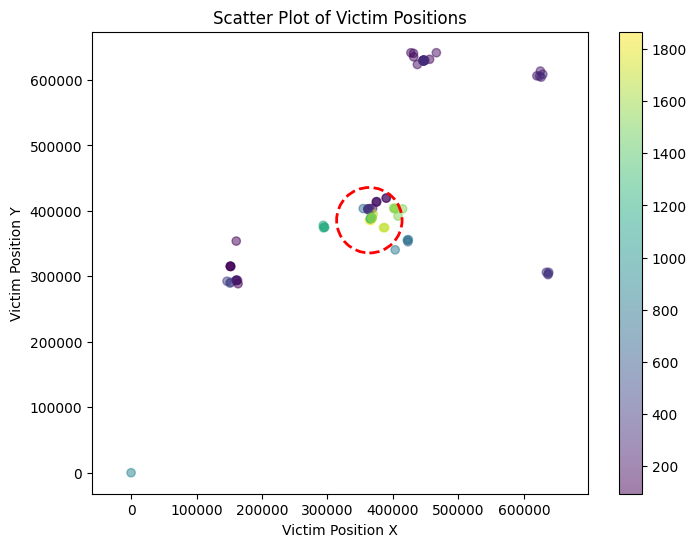


2 2U4GBNA0Ymk--IzbW-ihltP44UHbUvm7oAku86yTg7UOs4oWhJhsnTMzjwRkf72n
Number of rows for match_id 2U4GBNA0Ymk--IzbW-ihltP44UHbUvm7oAku86yTg7UOs4oWhJhsnTMzjwRkf72n: 85


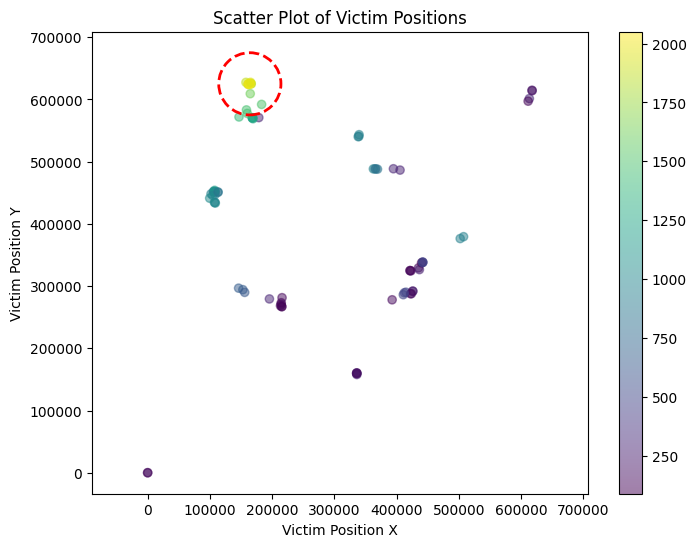

In [12]:
for i, match_id in enumerate(valid_match_ids):
    
    print(i, match_id)
    
    # filtered_df = df[df['match_id'] == match_id]
    # print(f"Number of rows for match_id {match_id}: {filtered_df.shape[0]}")

    filtered_df = erangel_death_df[erangel_death_df['match_id'] == match_id]
    print(f"Number of rows for match_id {match_id}: {filtered_df.shape[0]}")

    center_x = np.mean(filtered_df['victim_position_x'])
    center_y = np.mean(filtered_df['victim_position_y'])

    last_row = filtered_df.loc[filtered_df['time'].idxmax()]
    last_position_x = last_row['victim_position_x']
    last_position_y = last_row['victim_position_y']

    plt.figure(figsize=(8, 6))

    plt.scatter(filtered_df['victim_position_x'], filtered_df['victim_position_y'], 
                c=filtered_df['time'],
                alpha=0.5)
    
    plt.xlabel('Victim Position X')
    plt.ylabel('Victim Position Y')
    plt.title('Scatter Plot of Victim Positions')

    circle_radius = 50000  # 반지름 설정 (원하는 크기로 조정 가능)
    # circle = Circle((center_x, center_y), circle_radius, color='r', fill=False, linestyle='--', linewidth=2)
    circle = Circle((last_position_x, last_position_y), circle_radius, color='r', fill=False, linestyle='--', linewidth=2)
    plt.gca().add_patch(circle)
    
    plt.axis('equal')
    plt.colorbar()
    
    plt.show()

    print()
    
    if (i == 2): break

In [13]:
match_id = valid_match_ids[0]
    
filtered_df = erangel_death_df[erangel_death_df['match_id'] == match_id]
print(f"Number of rows for match_id {match_id}: {filtered_df.shape[0]}")


Number of rows for match_id 2U4GBNA0Ymk--3atnvB2Cy2-kmfWLqeLwaiFMfmzWQFhCkWmYZiq4XKDsLngboSq: 81


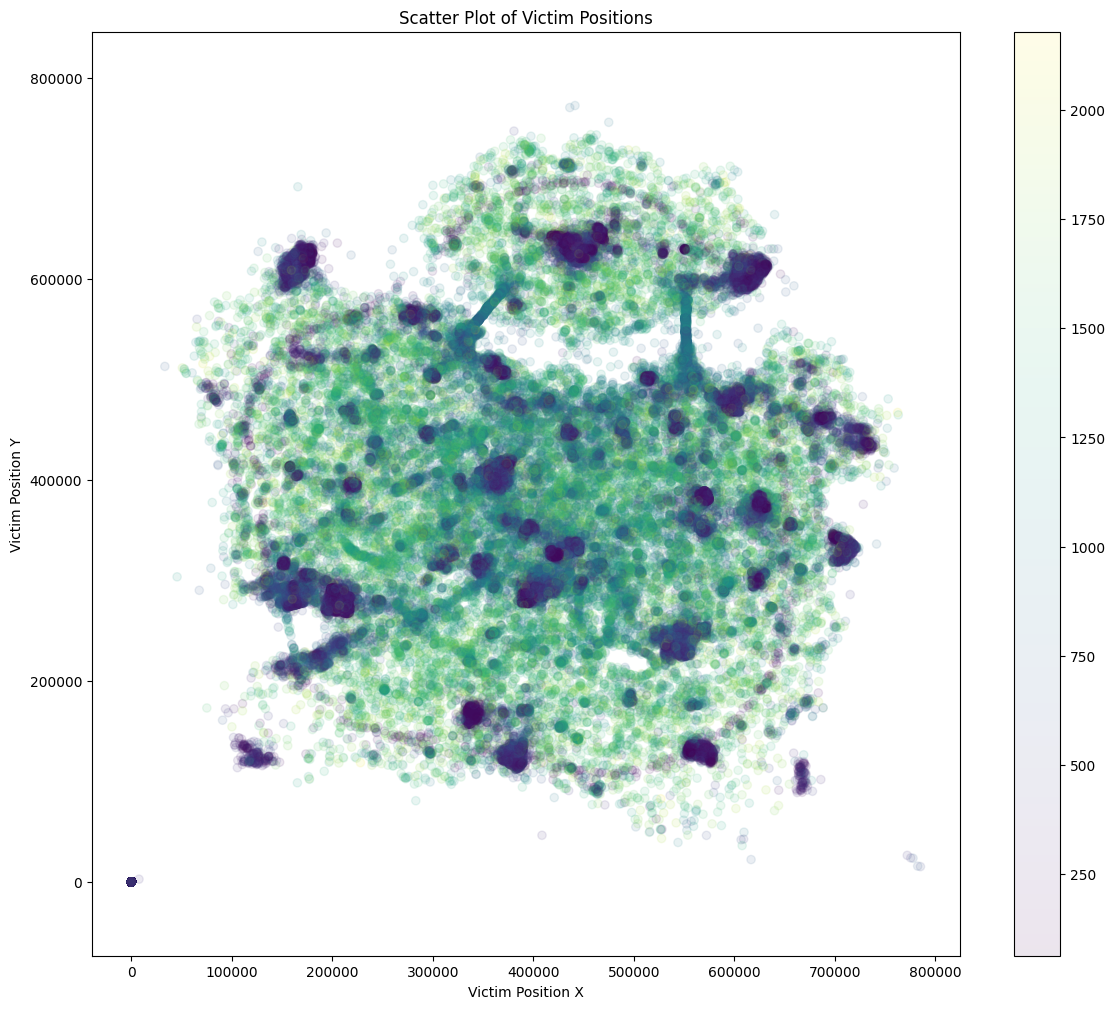

In [14]:
sampled_df = erangel_death_df.sample(frac=0.01, random_state=42)  # 1% of the data, can adjust frac

# Plotting
plt.figure(figsize=(14, 12))

plt.scatter(sampled_df['victim_position_x'], sampled_df['victim_position_y'], 
            c=sampled_df['time'],
            alpha=0.1)

plt.xlabel('Victim Position X')
plt.ylabel('Victim Position Y')
plt.title('Scatter Plot of Victim Positions')

plt.axis('equal')
plt.colorbar()

plt.show()

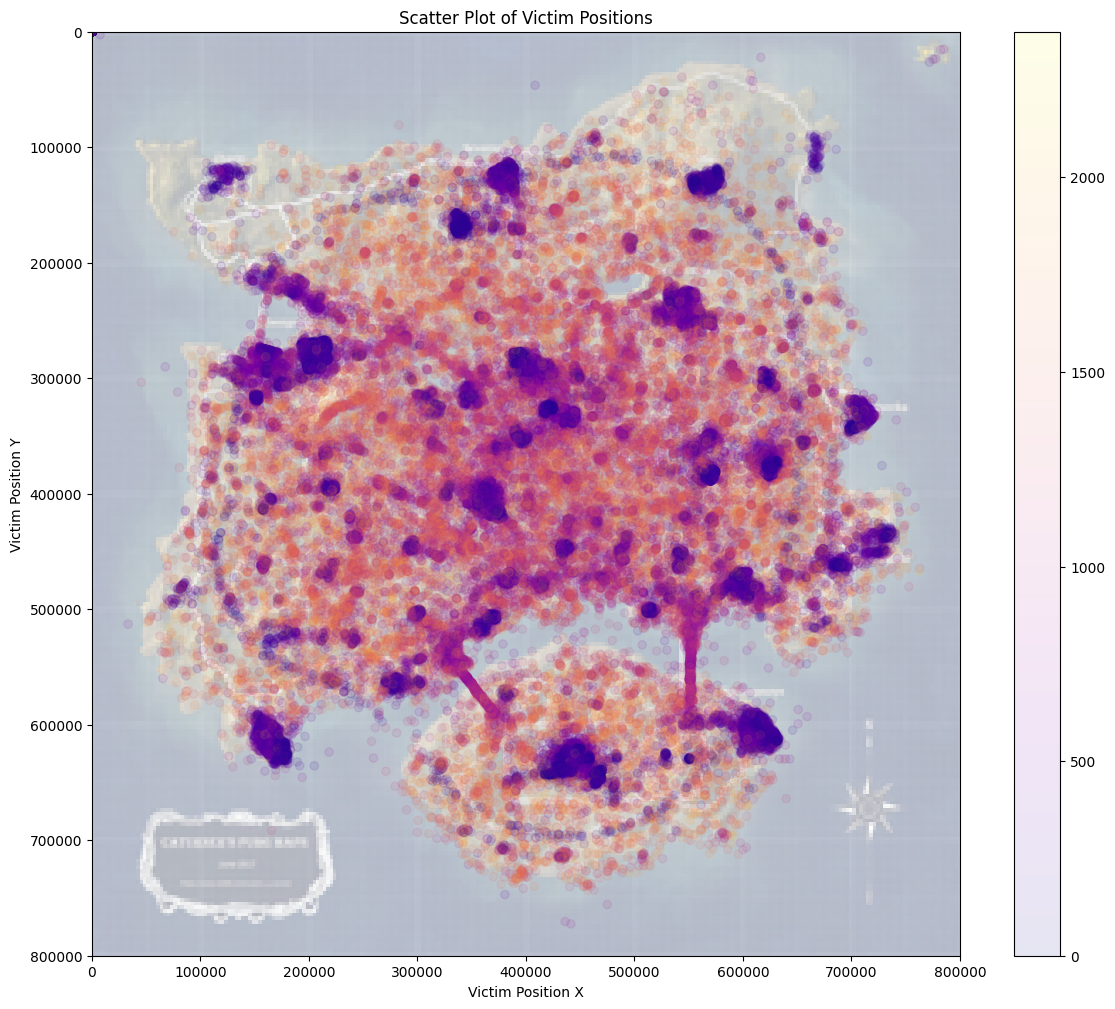

In [15]:
sampled_df = erangel_death_df.sample(frac=0.01, random_state=42)  # 1% of the data, can adjust frac

# Plotting
plt.figure(figsize=(14, 12))

plt.imshow(erangel_img, aspect='auto', extent=[0, 800000, 
                                       800000, 0], alpha=0.3)

plt.scatter(sampled_df['victim_position_x'], sampled_df['victim_position_y'], 
            c=sampled_df['time'],
            # cmap='YlOrRd',
            cmap='plasma',
            alpha=0.1,
            norm=mcolors.Normalize(vmin=0, vmax=max_time))

plt.xlabel('Victim Position X')
plt.ylabel('Victim Position Y')
plt.title('Scatter Plot of Victim Positions')

plt.xlim(0, 800000)
plt.ylim(0, 800000)

plt.gca().invert_yaxis()
# plt.axis('equal')
plt.axis('auto')
plt.colorbar()

plt.show()

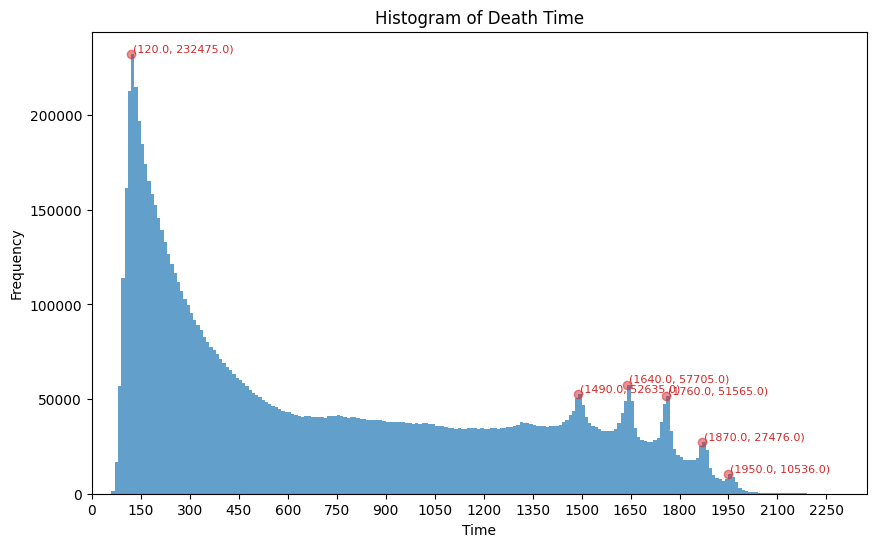

In [55]:
data = erangel_death_df['time']

plt.figure(figsize=(10, 6))

bins = list(range(0, max_time + 10, 10))
# bins = list(range(0, max_time + 1, 1))
counts, bins, patches = plt.hist(data, bins=bins, color='tab:blue', alpha=0.7)

peaks, _ = find_peaks(counts, threshold=1000)

plt.plot(bins[peaks], counts[peaks], "o", color='tab:red', alpha=0.5)

for peak in peaks:
    plt.text(bins[peak] + 5, counts[peak] + 100, f'({bins[peak]}, {counts[peak]})', 
             color='tab:red', ha='left', va='bottom', fontsize=8)

plt.xlabel('Time')
plt.ylabel('Frequency')
plt.title('Histogram of Death Time')

plt.xlim(0, max_time)
plt.xticks(range(0, max_time + 1, 150))

plt.show()

In [16]:
def format_ticks(x, pos):
    if x >= 1000:
        return f'{int(x / 1000)}k'
    return str(int(x))

In [ ]:
output_dir = "scatter_plots"

if os.path.exists(output_dir):
    for file_name in os.listdir(output_dir):
        os.remove(os.path.join(output_dir, file_name))
else:
    os.makedirs(output_dir)

# sampled_df = erangel_death_df.sample(frac=0.01, random_state=42)
sampled_df = erangel_death_df.sample(frac=0.01, random_state=42)

time_counts = sampled_df['time'].value_counts()
# max_time_bin = time_counts.idxmax()

for current_time in tqdm(range(min_time, max_time + 1), desc="Generating scatter plots", unit="time"):
    
    # filtered_df = sampled_df[sampled_df['time'] == current_time]
    filtered_df = sampled_df[(sampled_df['time'] >= current_time - 30) & (sampled_df['time'] <= current_time)]

    current_time_data_count = len(filtered_df[filtered_df['time'] == current_time])
    alpha_weight = time_counts.max() / current_time_data_count if current_time_data_count > 0 else 1
    alpha_weight = np.clip(alpha_weight, 1, 10)

    plt.figure(figsize=(7, 6))

    plt.imshow(erangel_img, aspect='auto', extent=[0, 800000, 800000, 0], alpha=0.3)

    if not filtered_df.empty:
        scatter = plt.scatter(filtered_df['victim_position_x'], filtered_df['victim_position_y'], 
                              c=filtered_df['time'], cmap='plasma', 
                              alpha=0.05 * alpha_weight, 
                              norm=mcolors.Normalize(vmin=0, vmax=max_time),
                              s=5)
    else:
        scatter = plt.scatter([], [], c=[], cmap='plasma', alpha=0.05, 
                              norm=mcolors.Normalize(vmin=0, vmax=max_time),
                              s=5)

    plt.xlabel('Victim Position X')
    plt.ylabel('Victim Position Y')
    plt.title(f'Scatter Plot of Victim Positions: Time = {current_time}')

    plt.xlim(0, 800000)
    plt.ylim(0, 800000)

    plt.gca().invert_yaxis()

    plt.axis('auto')

    plt.gca().xaxis.set_major_formatter(FuncFormatter(format_ticks))
    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_ticks))

    cbar = plt.colorbar(scatter)
    cbar.set_label('Time')    
    cbar.set_ticks([min_time, max_time])
    cbar.ax.axhline(y=current_time, color='tab:red', linewidth=1, linestyle='-')

    filename = os.path.join(output_dir, f"scatter_plot_{current_time:04d}.png")
    plt.savefig(filename, bbox_inches='tight')

    plt.close()

print(f"Scatter plots saved in the '{output_dir}' directory.")